In [1]:
def mergeSort(vetor):
  if len(vetor) <= 1:
    return vetor
  mid = len(vetor) // 2
  esquerda_metade = vetor[:mid]
  direita_metade = vetor[mid:]

  sorted_esquerda = mergeSort(esquerda_metade)
  sorted_direita = mergeSort(direita_metade)

  return merge(sorted_esquerda, sorted_direita)

def merge(esquerda, direita):
  result = []
  i = j = 0

  while i < len(esquerda) and j < len(direita):
    if esquerda[i] < direita[j]:
      result.append(esquerda[i])
      i += 1
    else:
      result.append(direita[j])
      j += 1

  result.extend(esquerda[i:])
  result.extend(direita[j:])

  return result

In [3]:
mergeSort([4,2,1,5])

[1, 2, 4, 5]

In [ ]:
def merge_sort(lista):
    if len(lista) > 1:
        esquerda = lista[:len(lista)//2]
        direita = lista[len(lista)//2:]

        merge_sort(esquerda)
        merge_sort(direita)

        index_esquerda = 0
        index_direita = 0
        index_merge = 0

        while index_esquerda < len(esquerda) and index_direita < len(direita):
            if esquerda[index_esquerda] <direita[index_direita]:
                lista[index_merge] = esquerda[index_esquerda]
                index_esquerda+=1
            else:
                lista[index_merge] = direita[index_direita]
                index_direita+=1
            index_merge+=1

        while index_esquerda < len(esquerda):
            lista[index_merge] = esquerda[index_esquerda]
            index_esquerda += 1
            index_merge += 1

        while index_direita < len(direita):
            lista[index_merge] = direita[index_direita]
            index_direita += 1
            index_merge += 1

# **Animação Merge Sort**

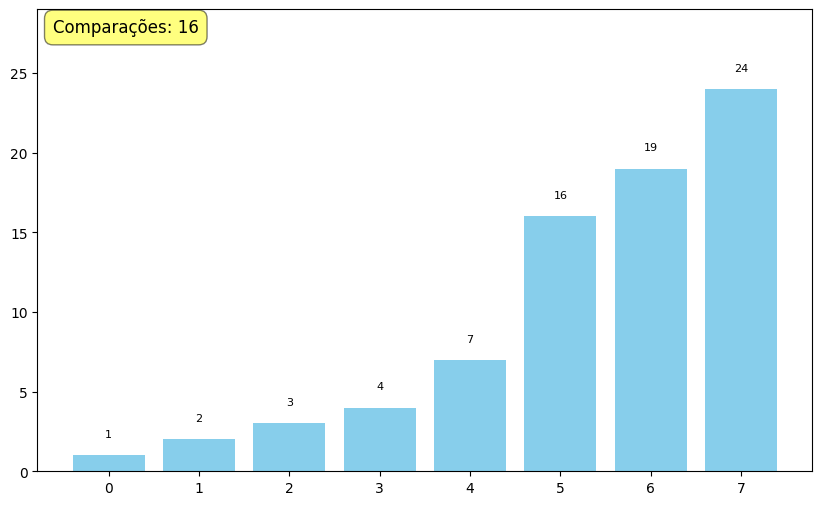

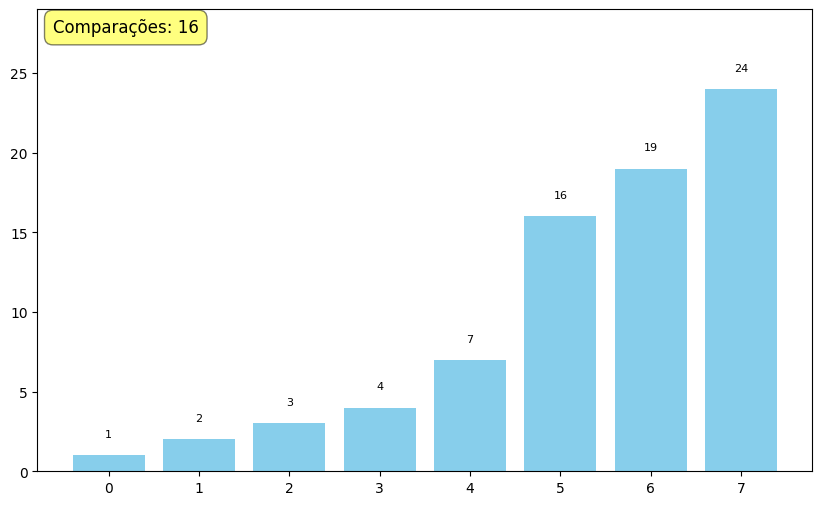

In [ ]:
import matplotlib.pyplot as plt
import random
import time
from IPython.display import display, clear_output

# fig and ax will be initialized once
fig, ax = None, None
comparisons = 0 # Initialize a global counter for comparisons

def merge_sort_visual(lista, draw_func):
    global comparisons # Declare intent to modify global comparisons
    if len(lista) > 1:
        meio = len(lista) // 2
        esquerda = lista[:meio]
        direita = lista[meio:]

        merge_sort_visual(esquerda, draw_func)
        merge_sort_visual(direita, draw_func)

        i = j = k = 0

        while i < len(esquerda) and j < len(direita):
            comparisons += 1 # Increment comparison counter
            if esquerda[i] < direita[j]:
                lista[k] = esquerda[i]
                i += 1
            else:
                lista[k] = direita[j]
                j += 1
            k += 1
            draw_func(lista)
            time.sleep(0.3)

        while i < len(esquerda):
            lista[k] = esquerda[i]
            i += 1
            k += 1
            draw_func(lista)
            time.sleep(0.3)

        while j < len(direita):
            lista[k] = direita[j]
            j += 1
            k += 1
            draw_func(lista)
            time.sleep(0.3)


def iniciar():
    global fig, ax, comparisons # Declare intent to modify global fig, ax, comparisons
    # Initialize figure and axes here, or re-initialize if needed
    if fig is None or not plt.fignum_exists(fig.number):
        fig, ax = plt.subplots(figsize=(10, 6))
    else:
        fig.clear()
        ax = fig.add_subplot(111)

    comparisons = 0 # Reset comparisons for each new run
    lista = [7,3,2,16,24,4,1,19]
    max_val = max(lista) if lista else 50 # Determine max value for consistent y-axis
    ax.set_ylim(0, max_val + 5) # Set y-limit to keep the scale consistent
    ax.set_title("Visualização Merge Sort")
    ax.set_xlabel("Índice")
    ax.set_ylabel("Valor")

    merge_sort_visual(lista, desenhar)
    clear_output(wait=True) # Clear the final animated output
    # Draw the final sorted state once without further clearing
    desenhar(lista)


def desenhar(lista):
    global ax, comparisons # Use the global ax and comparisons
    ax.clear() # Clear only the axes, not the entire figure
    bars = ax.bar(range(len(lista)), lista, color='skyblue')

    # Re-set Y-limit for consistency as ax.clear() might reset it
    ax.set_ylim(0, max(lista) + 5 if lista else 55)

    for bar in bars:
        yval = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, yval + 1, round(yval, 2), ha='center', va='bottom', fontsize=8)

    # Display comparison count
    ax.text(0.02, 0.98, f'Comparações: {comparisons}', transform=ax.transAxes, fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round,pad=0.5', fc='yellow', alpha=0.5))

    clear_output(wait=True) # Clear previous plot
    display(fig) # Display the updated figure


# Initial call to start the visualization
iniciar()